In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import sys
from scipy.stats import norm, poisson, chi2
from scipy.integrate import quad
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [2]:
def plot_fit (x_coord, y_coord, y_sigma, fit_function, minuit_object , title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 0.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label='dati sperimentali')

    x_fit = np.linspace (x_coord[0] -15, x_coord[-1]+15, 100)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label= 'fit')
    ax.set_xlabel (" N ")
    ax.set_ylabel ("cos(theta)")
    ax.set_title (title)
     #plt.legend('a = 1.585 ± 0.009' , 'b=0.10117 ± 0.01879μm2')
    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.grid(True)
    plt.show()
    #plt.close(fig)

def plot_fit_rig (x_coord, y_coord, y_sigma, fit_function, minuit_object , title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 0.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label='dati sperimentali')

    x_fit = np.linspace (x_coord[0] -1, x_coord[-1]+1, 100)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label= 'fit')
    ax.set_xlabel (" N ")
    ax.set_ylabel ("cos(theta)")
    ax.set_title (title)
     #plt.legend('a = 1.585 ± 0.009' , 'b=0.10117 ± 0.01879μm2')
    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.grid(True)
    plt.show()
    #plt.close(fig)

In [3]:
#parte 1
#N = [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1] #numero di frangia (1 = cerchio più lontano) dati completi
#R_N = [1.2, 2.0, 2.5, 2.9, 3.4, 3.7, 4.0 ,4.3, 4.5, 4.8, 5.1, 5.3, 5.6, 5.8, 6.0] #cm - raggio dei cerchi di interferenza dati completi
#N_tot =15


In [4]:
lamda = 632.8e-9 #m - lunghezza d'onda del laser è nota
#grandezze misurate
L0 = 1.37 #m - distanza dall’equivalente sorgente (punto virtuale tra specchi) allo schermo
errL0 = 0.01 #m
N = [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1] #numero di frangia (1 = cerchio più lontano)
#R_N_2 = [0.015, 0.023, 0.0275, 0.032, 0.036, 0.0395, 0.0425, 0.0455, 0.0480, 0.0510, 0.0535, 0.056, 0.0585, 0.0605, 0.0625]
err_RN = 0.0005  #m - mezzo mm di errore (righello)
N_tot = len(N)
R_N = [0.012, 0.020, 0.025, 0.029, 0.034, 0.037, 0.040 ,0.043, 0.045, 0.048, 0.051, 0.053, 0.056, 0.058, 0.060] #m - raggio dei cerchi dinterferenza
theta_N = []
err_theta_n = []
cos_theta = []
err_cos_theta = []

In [5]:
def theta (R_N):
    return np.arctan(R_N/L0)

def costheta (theta):
    return np.cos(theta)

def sigmatheta (R):
    return np.sqrt((err_RN/L0)**2 + ((R/L0**2)*errL0)**2)

def sigmacostheta (R):
    return np.sqrt((R/L0**2 * err_RN)**2 + (R**2/L0**3 * errL0)**2) / (1 + (R/L0)**2)**(3/2)




for i in range (N_tot):
    theta_N.append(theta(R_N[i]))
theta_N = np.array(theta_N)

for i in range (N_tot):
    cos_theta.append(costheta(theta_N[i]))
cos_theta = np.array(cos_theta)


for i in range (N_tot):
    err_theta_n.append(sigmatheta(R_N[i]))
err_theta_n = np.array(err_theta_n)

for i in range (N_tot):
    err_cos_theta.append(sigmacostheta(R_N[i]))
err_cos_theta = np.array(err_cos_theta)

print ('theta: ', theta_N, '+/-',err_theta_n)
print ('cos(theta): ',cos_theta, '+/-', err_cos_theta)

theta:  [0.0087589  0.0145975  0.01824615 0.02116472 0.02481243 0.02700074
 0.02918879 0.03137656 0.03283491 0.03502217 0.0372091  0.03866685
 0.04085317 0.0423105  0.04376765] +/- [0.00037052 0.0003802  0.00038851 0.00039632 0.00040745 0.0004148
 0.00042263 0.00043091 0.00043667 0.00044565 0.00045501 0.00046145
 0.0004714  0.00047822 0.00048517]
cos(theta):  [0.99996164 0.99989346 0.99983354 0.99977604 0.99969219 0.9996355
 0.99957404 0.9995078  0.99946098 0.99938679 0.99930782 0.99925253
 0.99916563 0.99910504 0.99904235] +/- [3.24506902e-06 5.54861171e-06 7.08606213e-06 8.38367841e-06
 1.01025050e-05 1.11904136e-05 1.23238436e-05 1.35050341e-05
 1.43200358e-05 1.55852224e-05 1.69031204e-05 1.78117569e-05
 1.92207851e-05 2.01913899e-05 2.11873889e-05]


In [6]:
#a = lamda/(2*d_reale) ------> trovo d
#b = -delta_r/(4*np.pi*d) ------> trovo delta r
#def maxtheta (N , d, b):
    #return (N*lamda)/(2*d) +b

def max_theta (N, a, b):
    return a*N + b

In [7]:
#minimi quadrati con a e b
least_squares = LeastSquares (N, cos_theta, err_cos_theta, max_theta)
my_minuit1 = Minuit (least_squares, a= 0.0, b= 0.0)
my_minuit1.migrad ()
my_minuit1.hesse ()


is_valid = my_minuit1.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit1.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit1.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit1.fval, df = my_minuit1.ndof))

for par, val, err in zip (my_minuit1.parameters, my_minuit1.values, my_minuit1.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

a_fit = my_minuit1.values[0]
a_err = my_minuit1.errors[0]
b_fit = my_minuit1.values[1]
b_err =my_minuit1.errors[1]


print (my_minuit1.covariance)


display (my_minuit1)

success of the fit:  True
value of the fit Q-squared 6.2060807520998065
value of the number of degrees of freedom 13.0
associated p-value:  0.9383298539949719
a = 0.000 +/- 0.000
b = 0.999 +/- 0.000
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 4.05e-13 -5.1e-12 │
│ b │ -5.1e-12  6.9e-11 │
└───┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.206 (χ²/ndof = 0.5)      │              Nfcn = 55               │
│ EDM = 4.91e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  65.0e-6  │  0.6e-6   │            │            │         │         │       │
│ 1 │ b    │998.987e-3 │ 0.008e-3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 4.05e-13 -5.1e-12 │
│ b │ -5.1e-12  6.9e-11 │
└───┴───────────────────┘

In [8]:
print ('a fit: ', a_fit, '+/-', a_err)
print ('b fit: ' ,b_fit, '+/-', b_err)
#a = lamda/(2*d) ------> trovo d
#b = -delta_r/(4*np.pi*d) ------> trovo delta r
d = lamda/(2*a_fit)
err_d = d * (a_err / a_fit)
delta_r = -b_fit*4*np.pi
err_delta= 4*np.pi*b_err

print ('d: ' , d, '+/-' , err_d)
print ('deltar: ', delta_r, '+/-', err_delta)


a fit:  6.498867459017038e-05 +/- 6.360401151709882e-07
b fit:  0.9989869580152173 +/- 8.304022233533225e-06
d:  0.004868540587960474 +/- 4.7648103855150366e-05
deltar:  -12.553640353330486 +/- 0.00010435142097645714


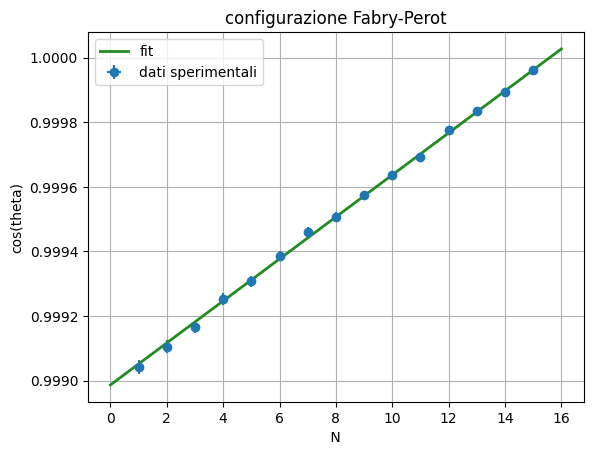

In [9]:
#fit lineari
#plot fit 1
plot_fit(N, cos_theta , err_cos_theta ,max_theta , my_minuit1, "configurazione Fabry-Perot")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)


In [10]:
#mettere i valori ricavati a e b e fare i eventuali t student
#perchè?





In [11]:
#parte 2 micrometro calibrazione

In [12]:
def d_real (cos_theta, delta_N):
    return (delta_N * lamda)/(2*cos_theta)

In [13]:
d_mm_nom = 20e-6 #spostamento in mum dello specchio mobile
err_d_mm_nom = 1e-6
delta_N_fp = 49
err_delta_N_fp = 1
costet=1 #perchè conto le frange vicino al centro


D_reale_fp = d_real(costet, delta_N_fp) #distanza tra i due specchi
err_D_reale_fp = (lamda/(2*costet)*err_delta_N_fp)
print ('D reale(correzione di d) per Fabry Perrot: ',D_reale_fp, '+/-', err_D_reale_fp)

D reale(correzione di d) per Fabry Perrot:  1.55036e-05 +/- 3.164e-07


In [14]:
fattore_di_calibrazione_fabry_perot = D_reale_fp/d_mm_nom #per avere il vero spostamento bisogna applicare questo fattore di correzione
k_cor_fp = fattore_di_calibrazione_fabry_perot
err_k_fp = k_cor_fp * np.sqrt((err_D_reale_fp / D_reale_fp)**2 + (err_d_mm_nom / d_mm_nom)**2)
print('fattore di correzione per Fabry Perrot: ',k_cor_fp, '+/-',  err_k_fp)

fattore di correzione per Fabry Perrot:  0.7751799999999999 +/- 0.04186325932127119


In [37]:
#applico il fattore di calibrazione su d uscente dal fit
d_corretto = d * k_cor_fp
err_d_corretto = err_d
print ('d corretto: ', d_corretto, '+/-', err_d_corretto)

d corretto:  0.0037739952929751997 +/- 4.7648103855150366e-05


In [15]:
#parte Michealson

In [16]:
#calibrazione micrometro

In [17]:
d_mm_nom = 20e-6 #spostamento in mum dello specchio mobile
err_d_mm_nom = 1e-6
delta_N_M = 47 #numero di frange
err_delta_N_M = 1
costet=1 #perchè conto le frange vicino al centro

D_reale_M = d_real(costet, delta_N_M)  #distanza tra i due specchi
err_D_reale_M = (lamda/(2*costet)*err_delta_N_M)

print ('D reale(correzione di d) per Michealson: ',D_reale_M, '+/-', err_D_reale_M)

D reale(correzione di d) per Michealson:  1.48708e-05 +/- 3.164e-07


In [18]:
fattore_di_calibrazione_michealson = D_reale_M/d_mm_nom #per avere il vero spostamento bisogna applicare questo fattore di correzione
k_cor_M = fattore_di_calibrazione_michealson
err_k_M = k_cor_M * np.sqrt((err_D_reale_M / D_reale_M)**2 + (err_d_mm_nom / d_mm_nom)**2)

print('fattore di correzione per Michealson: ',k_cor_M, '+/-',  err_k_M)

fattore di correzione per Michealson:  0.74354 +/- 0.04040299158478243


In [19]:
#confonto tra i due fattori di conversione (Fabry-Perot vs Michealson)
print (k_cor_fp, '+/-', err_k_fp)
print (k_cor_M, '+/-', err_k_M)
print ('meglio Michealson')

0.7751799999999999 +/- 0.04186325932127119
0.74354 +/- 0.04040299158478243
meglio Michealson


In [20]:
#indice di rifrazione dell'aria

In [21]:
s_a = 0.03 #spessore cella (PASCO)
Pi = 101325 #Pa - pressione atmosferica
Pf = 101325-76000 #Pa
delta_P = Pi - Pf
err_delta_P = 100
N_fa = 17
err_N_fa = 1


In [22]:
def maria (N_fa, delta_P):
    return (N_fa * lamda)/(2*s_a*delta_P)

m_aria = maria(N_fa, delta_P)
err_maria = m_aria * np.sqrt((err_N_fa / N_fa)**2 + (err_delta_P / delta_P)**2)
n_aria = m_aria * Pi +1
err_naria = Pi * err_maria

#def naria (N_fa, cos_theta):
    #return ((2*d-N_fa*lamda)*(1-cos_theta))/((2*d)*(1-cos_theta)-(N_fa*lamda))
#n_aria = naria (N_fa, cos_theta_M)
print ('m aria: ',m_aria, '+/-', err_maria)
print ('indice di rifrazione n dell aria', n_aria, '+/-', err_naria)

m aria:  2.359122807017544e-09 +/- 1.3880664249108345e-10
indice di rifrazione n dell aria 1.000239038118421 +/- 1.406458305040903e-05


In [23]:
#indice di rifrazione del vetro

In [24]:
s_v = 0.006 #m
theta_i = np.radians(0)
theta_f = np.radians(5)
N_fv = 26 # parte da rivedere
err_N_fv = 1
delta_theta = theta_i - theta_f
err_delta_theta = theta_f*(5/100)
cos_dtheta = np.cos(delta_theta)
err_cos_theta= np.abs(np.sin(delta_theta)) * err_delta_theta
print(cos_dtheta, '+/-', err_cos_theta)

0.9961946980917455 +/- 0.0003802886682419511


In [25]:
def nvetro (N_fa, cos_theta, d):
    return ((2*d-N_fa*lamda)*(1-cos_theta))/((2*d)*(1-cos_theta)-(N_fa*lamda))

n_vetro= nvetro(N_fv, cos_dtheta, s_v)

#parametri per errore n_vetro
D = 2*s_v*(1 - cos_dtheta) - N_fv*lamda

dn_dN = (lamda * 2*s_v * (1 - cos_dtheta) * cos_dtheta) / D**2
dn_dcostheta = (2*s_v * N_fv * lamda) / D**2
#fine parametri

err_nvetro = np.sqrt((dn_dN * err_N_fv)**2 + (dn_dcostheta * err_cos_theta)**2)

print ('indice di rifrazione del vetro n_vetro: ', n_vetro, '+/-', err_nvetro)

indice di rifrazione del vetro n_vetro:  1.5610999794632618 +/- 0.09423821030851334


In [26]:
n_aria_reale = 1.000293
n_vetro_reale = 1.52

t_student_aria = np.abs(n_aria_reale - n_aria )/err_naria
t_student_vetro =np.abs(n_vetro_reale - n_vetro )/err_nvetro

print('t student n aria: ', t_student_aria)
print('t student n vetro: ', t_student_vetro)

t student n aria:  3.8367210308139885
t student n vetro:  0.436128607798369


In [27]:
#parte righello

In [28]:
d_rig = 0.0005 #m - passo del righello = 1 mm
L_r = 1.20 #m - distanza schermo-righello
err_Lr = 0.01 #m
P0 = 0.080 #m
Pt = -0.080
delta_Pt_P0 = P0 - Pt
err_delta_Pt_P0 = 0.001 #m
N_r = [0,1,2,3,4,5,6,7,8,9,10,11,12,13] #n bande
Pn = [0.08, 0.1085, 0.1285, 0.1450, 0.1595, 0.173, 0.186, 0.198, 0.209, 0.218, 0.228, 0.2423, 0.2465, 0.2560] #m - distanza dallo 0 (parto da n=1)
#Pn = [0.08, 0.1085, 0.1285, 0.1450, 0.1595, 0.173, 0.186, 0.198, 0.209, 0.218, 0.228, 0.238, 0.2475, 0.2570] #m - distanza dallo 0 (parto da n=1)


In [29]:
def thetai (P0):
    return np.arctan(P0/L_r)

def sigmathetai (L_r, P0):
    return np.sqrt((L_r / (L_r**2 + P0**2) * err_delta_Pt_P0)**2 + (P0 / (L_r**2 + P0**2) * err_Lr)**2)

def thetan (delta_xN):
    return np.arctan(delta_xN/L_r)

def sigmathetatan (delta_xN):
    return (delta_xN / (L_r**2 + delta_xN**2)) * err_Lr

theta_n= []
for i in range(len(N_r)):
    theta_n.append(thetan(Pn[i]))

err_thetan = []
for i in range (len(N_r)):
    err_thetan.append(sigmathetatan(Pn[i]))

theta_n= np.array(theta_n)
err_thetan = np.array(err_thetan)

theta_i = thetai(P0)
err_theta_i = sigmathetai(L_r, P0)

print (theta_n, err_thetan)

[0.06656816 0.09017148 0.10667682 0.12025035 0.13214212 0.14318015
 0.1537763  0.16352662 0.17243698 0.17970683 0.18776195 0.19923783
 0.20259843 0.21018259] [0.0005531  0.00074736 0.00088224 0.00099245 0.00108841 0.00117693
 0.00126136 0.00133856 0.00140866 0.00146552 0.00152817 0.00161672
 0.0016425  0.00170039]


In [30]:
def sigmacosthetan (theta, err_theta):
    return np.abs(np.sin(theta)) * err_theta

cos_theta_i = np.cos(theta_i)
err_cos_theta_i = np.abs(np.sin(theta_i)) * err_theta_i
cos_theta_n = []
err_cos_theta_n = []

for i in range (len(theta_n)):
    cos_theta_n.append(np.cos(theta_n[i]))

for i in range (len(theta_n)):
    err_cos_theta_n.append(sigmacosthetan(theta_n[i], err_thetan[i]))

cos_theta_n = np.array(cos_theta_n)
err_cos_theta_n = np.array(err_cos_theta_n)

print ('n: ', cos_theta_n, '+/-', err_cos_theta_n)
print ('i: ', cos_theta_i, '+/-' , err_cos_theta_i)

n:  [0.99778516 0.99593731 0.99431542 0.99277863 0.99128193 0.98976722
 0.98819971 0.98665929 0.98516955 0.98389614 0.98242445 0.98021771
 0.97954704 0.97799284] +/- [3.67914881e-05 6.72994849e-05 9.39366445e-05 1.19055519e-04
 1.43406620e-04 1.67937494e-04 1.93204088e-04 2.17915575e-04
 2.41702849e-04 2.61949163e-04 2.85248550e-04 3.19985817e-04
 3.30495843e-04 3.54766998e-04]
i:  0.9977851578566089 +/- 6.632679846144791e-05


In [31]:
def rigg (N_r, lamda_inc, cos_thetai):
    return -(lamda_inc/d_rig)*N_r + cos_thetai

In [32]:
#minimi quadrati righello
least_squares = LeastSquares (N_r, cos_theta_n, err_cos_theta_n, rigg)
my_minuit2 = Minuit (least_squares, lamda_inc=0.0, cos_thetai=0.0)
my_minuit2.migrad ()
my_minuit2.hesse ()


is_valid = my_minuit2.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit2.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit2.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit2.fval, df = my_minuit2.ndof))

for par, val, err in zip (my_minuit2.parameters, my_minuit2.values, my_minuit2.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output


lamda_fit = my_minuit2.values[0]
er_lamda =my_minuit2.errors[0]
cos_thetai = my_minuit2.values[1]
err_cos_thetai = my_minuit2.errors[1]


print (my_minuit2.covariance)


display (my_minuit2)

success of the fit:  True
value of the fit Q-squared 36.99078002035151
value of the number of degrees of freedom 12.0
associated p-value:  0.00022417659396212208
lamda_inc = 0.000 +/- 0.000
cos_thetai = 0.998 +/- 0.000
┌────────────┬───────────────────────┐
│            │  lamda_inc cos_thetai │
├────────────┼───────────────────────┤
│  lamda_inc │   2.72e-17 82.843e-15 │
│ cos_thetai │ 82.843e-15   9.95e-10 │
└────────────┴───────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 36.99 (χ²/ndof = 3.1)      │              Nfcn = 53               │
│ EDM = 1.09e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name       │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ lamda_inc  │  783e-9   │   5e-9    │            │            │         │         │       │
│ 1 │ cos_thetai │997.682e-3 │ 0.032e-3  │            │            │         │         │       │
└───┴────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────────┬───────────────────────┐
│            │  lamda_inc cos_thetai │
├────────────┼───────────────────────┤
│  lamda_inc │   2.72e-17 82.843e-15 │
│ cos_thetai │ 82.843e-15   9.95e-10 │
└────────────┴───────────────────────┘

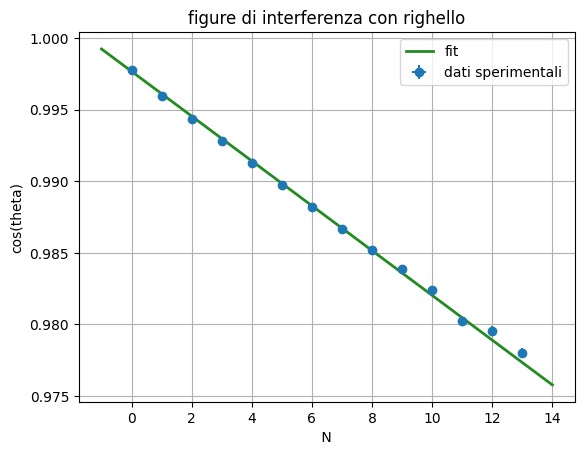

In [33]:
#fit lineari
#plot fit 1
plot_fit_rig(N_r, cos_theta_n , err_cos_theta_n ,rigg , my_minuit2, "figure di interferenza con righello")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)


In [34]:
print ('lamda del fit: ',lamda_fit,'+/-', er_lamda)
print ('cos theta i dal fit: ', cos_thetai, '+/-', err_cos_thetai)

lamda del fit:  7.827019297419177e-07 +/- 5.214666328613816e-09
cos theta i dal fit:  0.9976819651744893 +/- 3.1546922505991734e-05


In [35]:
t_student_lamda = np.abs((lamda_fit - lamda)/er_lamda)
t_student_theta = np.abs((cos_thetai - cos_theta_i)/err_cos_thetai)

print(t_student_lamda, t_student_theta)

28.746216976411073 3.271085542498441
